<a href="https://colab.research.google.com/github/thuBv-123/Bai-tap-buoi-2/blob/main/Nhan%20dien%20mon%20an.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Nhận diện món ăn Việt Nam

import numpy as np
import os
import matplotlib.pyplot as plt
from keras.utils import load_img, img_to_array,to_categorical
from keras.models import load_model, Sequential
from keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split

def load_images_and_labels(folder_path,target_size=(32,32)):
  imgs=[]
  labels=[]
  class_names=os.listdir(folder_path)
  class_label={name:i for i, name in enumerate(class_names)}
  for label in class_names:
    class_folder=os.path.join(folder_path,label)
    for filename in os.listdir(class_folder):
      file_path=os.path.join(class_folder,filename)
      try:
        img=load_img(file_path,target_size=target_size)
        img_array=img_to_array(img)/255
        imgs.append(img_array)
        labels.append(class_label[label])
      except:
        print(f"Lỗi khi xử lý ảnh: {file_path}")
  return np.array(imgs),to_categorical(labels),class_names


train_dir='/content/drive/MyDrive/FOOD_TRAIN'
val_dir='/content/drive/MyDrive/FOOD_VAL'


x_train, y_train, class_names = load_images_and_labels(train_dir)
x_val, y_val, _ = load_images_and_labels(val_dir)
x_train=x_train.reshape(len(x_train),32*32*3)
x_train=x_train.astype('float32')/255
x_val=x_val.reshape(len(x_val),32*32*3)
x_val=x_val.astype('float32')/255


model=Sequential([
    Dense(3000,activation='relu',input_shape=(32*32*3,)),
    Dense(500,activation='relu'),
    Dense(len(class_names),activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy',metrics=['accuracy'])
history=model.fit(x_train,y_train,epochs=50,batch_size=64, validation_data=(x_val,y_val))


Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.1667 - loss: 1.6094 - val_accuracy: 0.1000 - val_loss: 1.6106
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.6333 - loss: 1.6034 - val_accuracy: 0.3000 - val_loss: 1.6137
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 552ms/step - accuracy: 0.7333 - loss: 1.5931 - val_accuracy: 0.3000 - val_loss: 1.6178
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.7667 - loss: 1.5791 - val_accuracy: 0.2000 - val_loss: 1.6231
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.7667 - loss: 1.5602 - val_accuracy: 0.2000 - val_loss: 1.6290
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.8000 - loss: 1.5354 - val_accuracy: 0.2000 - val_loss: 1.6352
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.8000 - loss: 1.5034 - val_accuracy: 0.2000 - val_loss: 1.6419
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.8667 - loss: 1.4631 - val_accuracy: 0.1000 - val_loss: 1.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


Text(0.5, 1.0, 'Món này là:phở bò')

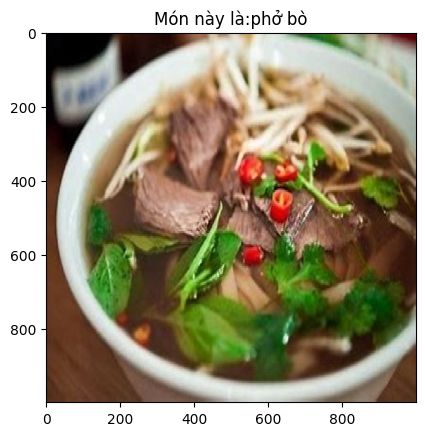

In [ ]:
img = load_img('/content/3.jpg',target_size=(1000,1000))
plt.imshow(img)

img_array=img_to_array(img.resize((32,32)))/255
img_array=img_to_array(img_array)

img_flat=img_array.reshape(1, -1)
prediction=model.predict(img_flat)
predicted_class = class_names[np.argmax(prediction)]

plt.title(f'Món này là:{predicted_class}')
